# Uniswap V2 — Simulateur d’arbitrage (CEX vs AMM), fees & analyses paramétriques



In [1]:
import numpy as np
import matplotlib.pyplot as plt


try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False


## 1) Fonctions communes (à réutiliser partout)

Tout ce qui suit sert de base à **toutes** les expériences.

In [2]:
from dataclasses import dataclass
from typing import Optional, Dict, Tuple


DAYS_PER_YEAR = 365.0
HOURS_PER_YEAR = DAYS_PER_YEAR * 24.0
MINUTES_PER_YEAR = HOURS_PER_YEAR * 60.0

def years_from_days(days: float) -> float:
    return days / DAYS_PER_YEAR

def years_from_minutes(minutes: float) -> float:
    return minutes / MINUTES_PER_YEAR

# Prix CEX : GBM (Mouvement Brownien Géométrique)

def make_time_grid(T: float, dt: float) -> np.ndarray:
    N = int(np.round(T / dt)) + 1  # round pour éviter les erreurs de flottants
    return np.linspace(0.0, T, N)

def brownian_path(N: int, dt: float, seed: Optional[int] = None) -> np.ndarray:
    '''
    Génère W_t discretisé (Brownien standard) :
      W[0]=0 ; W[i]=sum_{j<=i} Z_j * sqrt(dt)
    '''
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal(N)
    W = np.cumsum(Z) * np.sqrt(dt)
    W[0] = 0.0
    return W

def gbm_from_brownian(t: np.ndarray, W: np.ndarray, mu: float, sigma: float, S0: float) -> np.ndarray:
    '''Trajectoire GBM à partir d'un Brownien W.'''
    return S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

# -----------------------------
# Uniswap V2 : swaps exacts (avec frais)
# -----------------------------
def swap_y_for_x(x: float, y: float, amount_y_in: float, phi: float) -> Tuple[float, float, float, float]:
    '''
    Swap exact Uniswap V2 : on envoie Y dans la pool et on reçoit X.
    Frais prélevés sur l'input : fee = phi * amount_y_in.
    '''
    if amount_y_in <= 0:
        return x, y, 0.0, 0.0
    fee_y = phi * amount_y_in
    amount_in_eff = amount_y_in * (1.0 - phi)
    dx_out = x * amount_in_eff / (y + amount_in_eff)
    x_new = x - dx_out
    y_new = y + amount_y_in
    return x_new, y_new, dx_out, fee_y

def swap_x_for_y(x: float, y: float, amount_x_in: float, phi: float) -> Tuple[float, float, float, float]:
    '''
    Swap exact Uniswap V2 : on envoie X dans la pool et on reçoit Y.
    Frais prélevés sur l'input : fee = phi * amount_x_in.
    '''
    if amount_x_in <= 0:
        return x, y, 0.0, 0.0
    fee_x = phi * amount_x_in
    amount_in_eff = amount_x_in * (1.0 - phi)
    dy_out = y * amount_in_eff / (x + amount_in_eff)
    x_new = x + amount_x_in
    y_new = y - dy_out
    return x_new, y_new, dy_out, fee_x

def spot_price_y_per_x(x: float, y: float) -> float:
    '''Prix spot AMM : P = y/x (numéraire = Y).'''
    return y / x

# -----------------------------
# Arbitrage : taille de trade fermée (1 trade) pour atteindre un prix spot cible
# -----------------------------
def _solve_trade_y_in_for_target_price(x: float, y: float, phi: float, P_target: float) -> float:
    '''
    Trouve amount_y_in >= 0 tel que le prix spot après swap (Y->X) devienne P_target.

    On résout :
      P_after(a) = (y+a)(y+(1-phi)a)/(x*y) = P_target
    => (1-phi)a^2 + y(2-phi)a + y^2 - P_target*x*y = 0
    '''
    A = (1.0 - phi)
    B = y * (2.0 - phi)
    C = y*y - P_target * x * y

    disc = B*B - 4.0*A*C
    if disc <= 0:
        return 0.0
    a = (-B + np.sqrt(disc)) / (2.0*A)
    return max(0.0, float(a))

def _solve_trade_x_in_for_target_price(x: float, y: float, phi: float, P_target: float) -> float:
    '''
    Trouve amount_x_in >= 0 tel que le prix spot après swap (X->Y) devienne P_target.

    On résout :
      P_after(a) = y*x / ((x+(1-phi)a)(x+a)) = P_target
    => P_target(1-phi)a^2 + P_target*x(2-phi)a + P_target*x^2 - x*y = 0
    '''
    A = P_target * (1.0 - phi)
    B = P_target * x * (2.0 - phi)
    C = P_target * x * x - x * y

    disc = B*B - 4.0*A*C
    if disc <= 0 or A <= 0:
        return 0.0
    a = (-B + np.sqrt(disc)) / (2.0*A)
    return max(0.0, float(a))

@dataclass
class SimParams:
    # horizon & pas (en années)
    T: float = years_from_days(30.0)
    dt: float = years_from_minutes(10.0)

    # CEX (GBM)
    mu: float = 0.0
    sigma: float = 0.5
    S0: float = 1000.0
    seed: Optional[int] = 42

    # Uniswap V2
    phi: float = 0.003
    initial_liquidity_x: float = 10_000.0  # réserve initiale de X
    # on initialise y0 = x0 * S0 pour que P0 = S0

    # Arbitrage "réaction"
    alpha: float = 1.0              # 1.0 = arbitrage instantané (1 trade), <1 = ajustement progressif
    latency_minutes: float = 0.0    # délai avant arbitrage quand sortie de bande
    retarget: bool = True           # si True, la cible suit le CEX pendant la réaction

def simulate_uniswap_v2(params: SimParams, S_cex: Optional[np.ndarray] = None, W: Optional[np.ndarray] = None) -> Dict[str, np.ndarray]:
    '''
    Simule une pool Uniswap V2 arbitrée par rapport à un prix CEX.


    Modèle d'arbitrage (bande simple autour du prix AMM) :
      upper = P/(1-phi), lower = P*(1-phi)
    Si S_cex sort, l'arbitragiste ramène (plus ou moins vite) le spot AMM vers la frontière.
    '''
    t = make_time_grid(params.T, params.dt)
    N = len(t)

    # CEX path
    if S_cex is None:
        if W is None:
            W = brownian_path(N, params.dt, seed=params.seed)
        S_cex = gbm_from_brownian(t, W, params.mu, params.sigma, params.S0)
    else:
        S_cex = np.asarray(S_cex, dtype=float)
        if len(S_cex) != N:
            raise ValueError("S_cex doit avoir la même longueur que t (défini par T/dt).")

    # Pool state
    x = np.zeros(N)
    y = np.zeros(N)
    fee_x_cum = np.zeros(N)
    fee_y_cum = np.zeros(N)
    reacting = np.zeros(N, dtype=bool)

    x[0] = params.initial_liquidity_x
    y[0] = params.initial_liquidity_x * params.S0

    # Latency  (en steps)
    dt_minutes = params.dt * MINUTES_PER_YEAR
    latency_steps = int(round(params.latency_minutes / dt_minutes)) if params.latency_minutes > 0 else 0
    countdown = 0
    last_direction = 0  # +1 => Y->X (prix monte), -1 => X->Y (prix baisse), 0 => idle

    for i in range(1, N):
        x[i], y[i] = x[i-1], y[i-1]
        fee_x_cum[i], fee_y_cum[i] = fee_x_cum[i-1], fee_y_cum[i-1]

        P = spot_price_y_per_x(x[i], y[i])
        S = S_cex[i]

        upper = P / (1.0 - params.phi)
        lower = P * (1.0 - params.phi)

        # Détection : sortie de bande
        direction = 0
        if S > upper:
            direction = +1
        elif S < lower:
            direction = -1

        # Latence : si nouvelle sortie => on démarre un compte à rebours
        if direction != 0 and (last_direction == 0):
            countdown = latency_steps

        if direction == 0:
            countdown = 0
            last_direction = 0
            reacting[i] = False
            continue

        reacting[i] = True

        if countdown > 0:
            countdown -= 1
            last_direction = direction
            continue

        # Cible : frontière de non-arb (simple)
        # retarget : on réévalue direction/cible à chaque pas (si le CEX bouge)
        if params.retarget:
            P = spot_price_y_per_x(x[i], y[i])
            upper = P / (1.0 - params.phi)
            lower = P * (1.0 - params.phi)
            direction = +1 if S > upper else (-1 if S < lower else 0)
            if direction == 0:
                last_direction = 0
                reacting[i] = False
                continue

        if direction == +1:
            P_target = S * (1.0 - params.phi)
            amount_y_in_star = _solve_trade_y_in_for_target_price(x[i], y[i], params.phi, P_target)
            amount_y_in = params.alpha * amount_y_in_star
            x_new, y_new, _, fee_y = swap_y_for_x(x[i], y[i], amount_y_in, params.phi)
            x[i], y[i] = x_new, y_new
            fee_y_cum[i] += fee_y
        else:
            P_target = S / (1.0 - params.phi)
            amount_x_in_star = _solve_trade_x_in_for_target_price(x[i], y[i], params.phi, P_target)
            amount_x_in = params.alpha * amount_x_in_star
            x_new, y_new, _, fee_x = swap_x_for_y(x[i], y[i], amount_x_in, params.phi)
            x[i], y[i] = x_new, y_new
            fee_x_cum[i] += fee_x

        last_direction = direction

    P_amm = y / x
    fees_value_Y = fee_x_cum * S_cex + fee_y_cum  # conversion simple en numéraire Y au prix CEX instantané

    return {
        "t": t,
        "S_cex": S_cex,
        "x": x,
        "y": y,
        "P_amm": P_amm,
        "fee_x_cum": fee_x_cum,
        "fee_y_cum": fee_y_cum,
        "fees_value_Y": fees_value_Y,
        "reacting": reacting,
        "params": params,
    }


# Métriques & plots (communs)

def lp_value_Y(x: np.ndarray, y: np.ndarray, S: np.ndarray, lp_share: float = 1.0) -> np.ndarray:
    return lp_share * (x * S + y)

def hodl_value_Y(x0: float, y0: float, S: np.ndarray) -> np.ndarray:
    return x0 * S + y0

def summarize_run(out: Dict[str, np.ndarray], lp_share: float = 1.0) -> Dict[str, float]:
    S = out["S_cex"]
    x, y = out["x"], out["y"]

    x0 = x[0] * lp_share
    y0 = y[0] * lp_share
    V0 = x0 * S[0] + y0

    V_lp = lp_value_Y(x, y, S, lp_share=lp_share)
    V_hodl = hodl_value_Y(x0, y0, S)

    return {
        "V0_Y": float(V0),
        "V_lp_end_Y": float(V_lp[-1]),
        "V_hodl_end_Y": float(V_hodl[-1]),
        "LP_minus_HODL_end_Y": float(V_lp[-1] - V_hodl[-1]),
        "fees_end_Y": float(out["fees_value_Y"][-1]),
        "price_tracking_rmse": float(np.sqrt(np.mean((out["P_amm"] - out["S_cex"])**2))),
    }

def plot_basic(out: Dict[str, np.ndarray], title: str = "Expérience") -> None:
    t_days = out["t"] * DAYS_PER_YEAR
    S = out["S_cex"]
    P = out["P_amm"]
    x, y = out["x"], out["y"]
    fees = out["fees_value_Y"]

    plt.figure(figsize=(10, 4))
    plt.plot(t_days, S, label="Prix CEX")
    plt.plot(t_days, P, label="Prix AMM")
    plt.xlabel("Temps (jours)")
    plt.ylabel("Prix (Y par X)")
    plt.title(f"{title} — Prix")
    plt.grid(True); plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t_days, x, label="Réserve X")
    plt.plot(t_days, y, label="Réserve Y")
    plt.xlabel("Temps (jours)")
    plt.ylabel("Réserves")
    plt.title(f"{title} — Réserves")
    plt.grid(True); plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t_days, fees, label="Frais cumulés (valeur Y)")
    plt.xlabel("Temps (jours)")
    plt.ylabel("Frais (Y)")
    plt.title(f"{title} — Frais cumulés")
    plt.grid(True); plt.legend()
    plt.tight_layout()
    plt.show()
#
# Frais : agrégats (communs)

def total_fees_final_Y(out: Dict[str, np.ndarray], price_for_valuation: str = "amm") -> float:
    '''
    Retourne la valeur totale des frais (en Y) en valorisant le stock de frais en X
    au prix final.

    price_for_valuation:
      - "amm" : prix spot AMM final (P_amm[-1])
      - "cex" : prix CEX final (S_cex[-1])
    '''
    fee_x = float(out["fee_x_cum"][-1])
    fee_y = float(out["fee_y_cum"][-1])
    if price_for_valuation == "cex":
        P = float(out["S_cex"][-1])
    else:
        P = float(out["P_amm"][-1])
    return fee_y + fee_x * P

def simulate_on_price_path(
    S_path: np.ndarray,
    dt: float,
    *,
    phi: float,
    initial_liquidity_x: float,
    alpha: float = 1.0,
    latency_minutes: float = 0.0,
    retarget: bool = True,
) -> Dict[str, np.ndarray]:
    '''
    Wrapper "cohérent" : on garde simulate_uniswap_v2 comme coeur,
    mais on l'alimente avec un chemin de prix déjà construit.
    '''
    S_path = np.asarray(S_path, dtype=float)
    if S_path.ndim != 1 or len(S_path) < 2:
        raise ValueError("S_path doit être un vecteur 1D de longueur >= 2.")

    p = SimParams(
        T=(len(S_path)-1) * dt,
        dt=dt,
        mu=0.0, sigma=0.0,  # ignorés quand S_cex est fourni
        S0=float(S_path[0]),
        seed=None,
        phi=float(phi),
        initial_liquidity_x=float(initial_liquidity_x),
        alpha=float(alpha),
        latency_minutes=float(latency_minutes),
        retarget=bool(retarget),
    )
    return simulate_uniswap_v2(p, S_cex=S_path)


## 2) Expérience de base (même protocole)

On simule 30 jours, pas de 10 minutes, frais 0.3% (Uniswap V2 “classique”), arbitrage instantané (**alpha=1**).

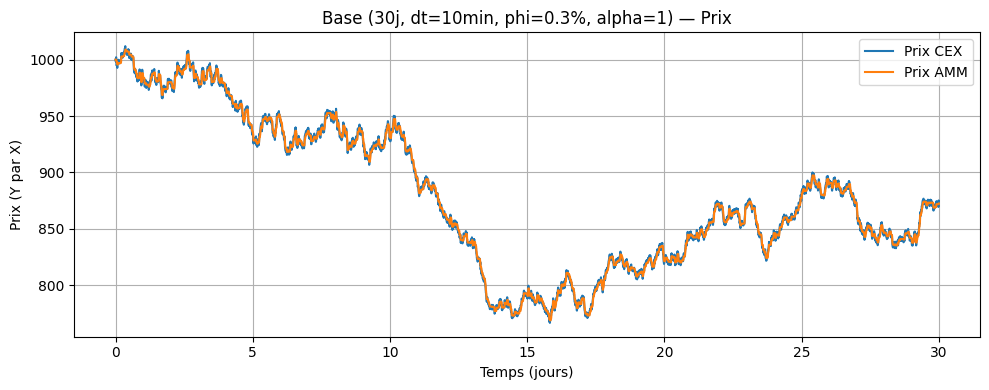

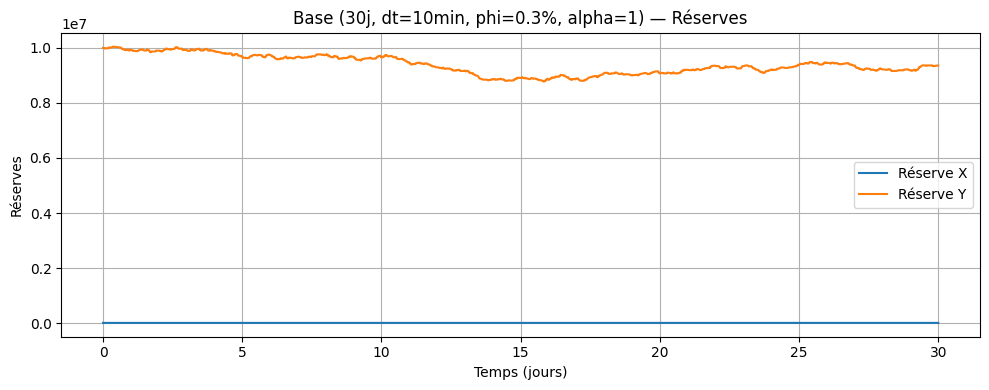

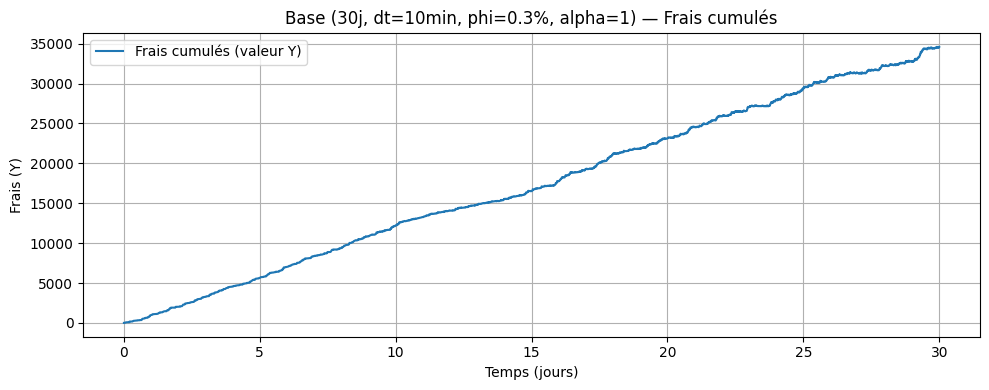

{'V0_Y': 20000000.0,
 'V_lp_end_Y': 18730478.850147195,
 'V_hodl_end_Y': 18738371.39411673,
 'LP_minus_HODL_end_Y': -7892.5439695343375,
 'fees_end_Y': 34604.73209253412,
 'price_tracking_rmse': 1.995628191329525}

In [3]:
params = SimParams(
    T=years_from_days(30),
    dt=years_from_minutes(10),
    mu=0.0,
    sigma=0.5,
    S0=1000.0,
    seed=42,
    phi=0.003,
    initial_liquidity_x=10_000.0,
    alpha=1.0,
    latency_minutes=0.0,
    retarget=True,
)

out = simulate_uniswap_v2(params)
plot_basic(out, title="Base (30j, dt=10min, phi=0.3%, alpha=1)")

summary = summarize_run(out)
summary

## 3) Zoom “bande de réaction” (latence + ajustement progressif)

Même modèle, mais :
- **latency_minutes** : délai avant que l’arbitrage démarre
- **alpha < 1** : on exécute seulement une fraction de la taille de trade optimale à chaque pas

Ça reproduit l’idée de “réaction” (sans dupliquer le code).

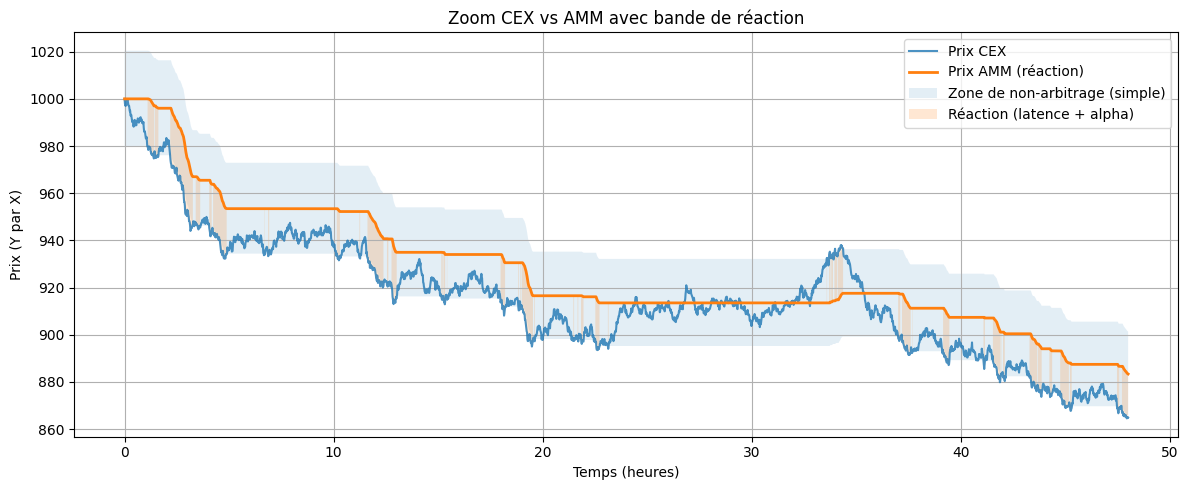

{'V0_Y': 20000000.0,
 'V_lp_end_Y': 18613311.472110905,
 'V_hodl_end_Y': 18648797.98041243,
 'LP_minus_HODL_end_Y': -35486.50830152631,
 'fees_end_Y': 12019.934109855361,
 'price_tracking_rmse': 14.1385091720432}

In [4]:
zoom_params = SimParams(
    T=years_from_days(2),
    dt=years_from_minutes(1),   # 1 minute
    mu=0.0,
    sigma=0.8,
    S0=1000.0,
    seed=10,
    phi=0.02,                   # 2% de frais (juste pour visualiser des bandes plus larges)
    initial_liquidity_x=10_000.0,
    alpha=0.12,                 # ajustement progressif
    latency_minutes=3.0,        # latence
    retarget=True,
)

zoom = simulate_uniswap_v2(zoom_params)

# Plot : prix + zones (bande de non-arbitrage)
t_hours = zoom["t"] * HOURS_PER_YEAR
S = zoom["S_cex"]
P = zoom["P_amm"]
phi = zoom_params.phi

upper = P / (1 - phi)
lower = P * (1 - phi)
reacting = zoom["reacting"]

plt.figure(figsize=(12, 5))
plt.plot(t_hours, S, label="Prix CEX", alpha=0.8)
plt.plot(t_hours, P, label="Prix AMM (réaction)", linewidth=2)
plt.fill_between(t_hours, lower, upper, alpha=0.12, label="Zone de non-arbitrage (simple)")
plt.fill_between(t_hours, P, S, where=reacting, alpha=0.18, label="Réaction (latence + alpha)")
plt.title(r"Zoom CEX vs AMM avec bande de réaction")
plt.xlabel("Temps (heures)")
plt.ylabel("Prix (Y par X)")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

summarize_run(zoom)

## 4) Études paramétriques (toujours le même protocole)

Idée : on fixe une grille de temps et un Brownien **W** (donc le “hasard”), puis on varie un paramètre à la fois.
Ainsi, les expériences sont comparables (toutes choses égales par ailleurs).

In [5]:
# Base commune pour les sweeps : on fige un Brownien unique (1 minute) assez long
# pour couvrir T_max utilisé dans le notebook (jusqu'à 365 jours).
dt_sweep = years_from_minutes(1)

T_sweep = years_from_days(30)              # horizon "standard" pour la plupart des sweeps
t_sweep = make_time_grid(T_sweep, dt_sweep)

T_sweep_max = years_from_days(365)         # horizon max (utilisé dans le sweep sur T)
t_sweep_max = make_time_grid(T_sweep_max, dt_sweep)

# Un seul Brownien long ; toutes les expériences prendront un préfixe de ce chemin
W_sweep = brownian_path(len(t_sweep_max), dt_sweep, seed=123)
W_sweep_30 = W_sweep[:len(t_sweep)]        # préfixe 30 jours pour la plupart des expériences  (pratique) mai

base = SimParams(
    T=T_sweep,
    dt=dt_sweep,
    mu=0.0,
    sigma=0.5,
    S0=1000.0,
    seed=None,               # on passe W à la main
    phi=0.003,
    initial_liquidity_x=10_000.0,
    alpha=1.0,
    latency_minutes=0.0,
    retarget=True,
)

def run_with_sigma(sigma_value: float):
    p = SimParams(**{**base.__dict__, "sigma": float(sigma_value)})
    S_path = gbm_from_brownian(t_sweep, W_sweep_30, p.mu, p.sigma, p.S0)
    return simulate_uniswap_v2(p, S_cex=S_path)

def run_with_mu(mu_value: float):
    p = SimParams(**{**base.__dict__, "mu": float(mu_value)})
    S_path = gbm_from_brownian(t_sweep, W_sweep_30, p.mu, p.sigma, p.S0)
    return simulate_uniswap_v2(p, S_cex=S_path)

def run_with_liquidity(Lx: float):
    p = SimParams(**{**base.__dict__, "initial_liquidity_x": float(Lx)})
    S_path = gbm_from_brownian(t_sweep, W_sweep_30, p.mu, p.sigma, p.S0)
    return simulate_uniswap_v2(p, S_cex=S_path)


### 4.1) Fees en fonction de la volatilité σ

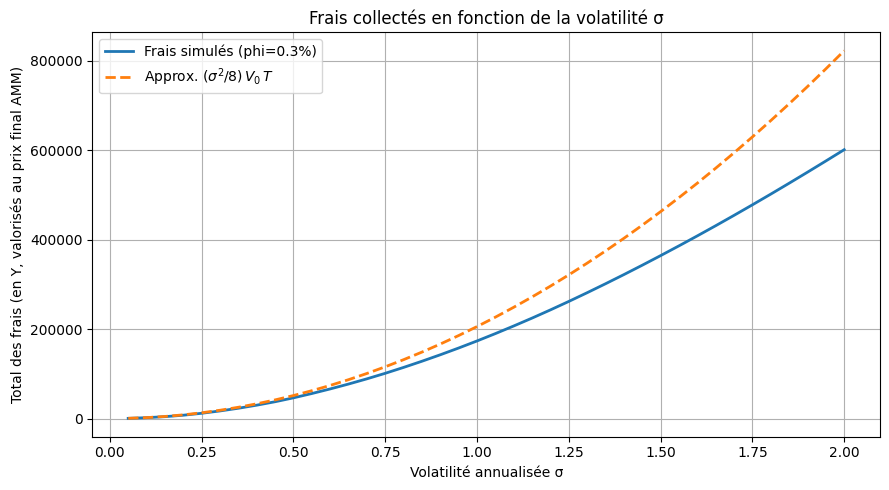

In [6]:
sigmas = np.linspace(0.05, 2.0, 40)
fees_vs_sigma = []
theoretical = []

# Valeur initiale de la pool en Y (approx) : V0 = x0*S0 + y0 = 2*x0*S0
V0 = 2.0 * base.initial_liquidity_x * base.S0

for s in sigmas:
    out_s = run_with_sigma(s)
    fees_vs_sigma.append(total_fees_final_Y(out_s, price_for_valuation="amm"))
    # Même comparaison que dans ton notebook (limite continue, approx)
    theoretical.append((s**2 / 8.0) * V0 * base.T)

plt.figure(figsize=(9, 5))
plt.plot(sigmas, fees_vs_sigma, linewidth=2, label=f"Frais simulés (phi={base.phi*100:.1f}%)")
plt.plot(sigmas, theoretical, linestyle="--", linewidth=2, label=r"Approx. $(\sigma^2/8)\,V_0\,T$")
plt.title("Frais collectés en fonction de la volatilité σ")
plt.xlabel("Volatilité annualisée σ")
plt.ylabel("Total des frais (en Y, valorisés au prix final AMM)")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

### 4.2) Fees en fonction de la liquidité initiale

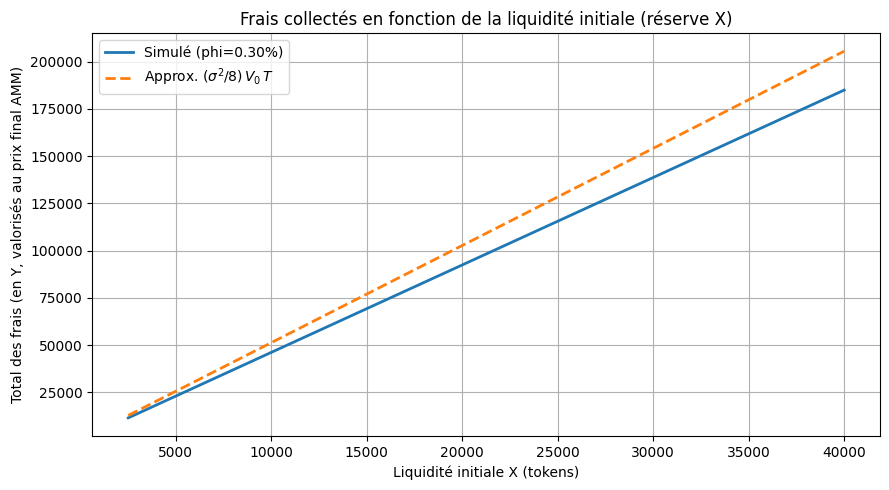

In [7]:
liq_factors = np.linspace(0.25, 4.0, 40)
liq_grid = liq_factors * base.initial_liquidity_x
fees_vs_liq = []
theoretical_liq = []

for Lx in liq_grid:
    out_L = run_with_liquidity(Lx)
    fees_vs_liq.append(total_fees_final_Y(out_L, price_for_valuation="amm"))
    V0_L = 2.0 * Lx * base.S0
    theoretical_liq.append((base.sigma**2 / 8.0) * V0_L * base.T)

plt.figure(figsize=(9, 5))
plt.plot(liq_grid, fees_vs_liq, linewidth=2, label=f"Simulé (phi={base.phi*100:.2f}%)")
plt.plot(liq_grid, theoretical_liq, linestyle="--", linewidth=2, label=r"Approx. $(\sigma^2/8)\,V_0\,T$")
plt.title("Frais collectés en fonction de la liquidité initiale (réserve X)")
plt.xlabel("Liquidité initiale X (tokens)")
plt.ylabel("Total des frais (en Y, valorisés au prix final AMM)")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

### 4.3) Fees en fonction de l’horizon (T)

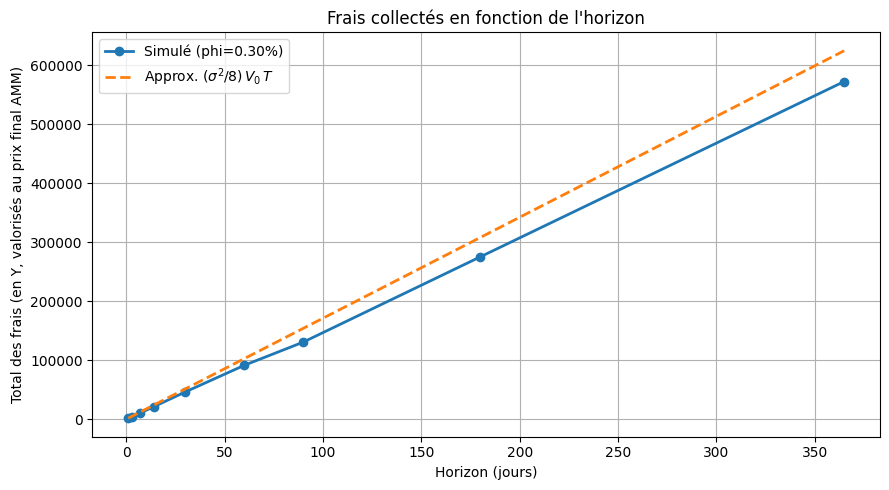

In [8]:
days_grid = np.array([1, 3, 7, 14, 30, 60, 90, 180, 365])
fees_vs_T = []
theoretical_T = []

for d in days_grid:
    p = SimParams(**{**base.__dict__, "T": years_from_days(float(d))})
    t_local = make_time_grid(p.T, p.dt)
    W_local = W_sweep[:len(t_local)]  # tronquage pour garder le même hasard
    S_path = gbm_from_brownian(t_local, W_local, p.mu, p.sigma, p.S0)
    out_T = simulate_uniswap_v2(p, S_cex=S_path)
    fees_vs_T.append(total_fees_final_Y(out_T, price_for_valuation="amm"))

    V0_T = 2.0 * p.initial_liquidity_x * p.S0
    theoretical_T.append((p.sigma**2 / 8.0) * V0_T * p.T)

plt.figure(figsize=(9, 5))
plt.plot(days_grid, fees_vs_T, marker="o", linewidth=2, label=f"Simulé (phi={base.phi*100:.2f}%)")
plt.plot(days_grid, theoretical_T, linestyle="--", linewidth=2, label=r"Approx. $(\sigma^2/8)\,V_0\,T$")
plt.title("Frais collectés en fonction de l'horizon")
plt.xlabel("Horizon (jours)")
plt.ylabel("Total des frais (en Y, valorisés au prix final AMM)")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

### 4.4) Fees en fonction du drift μ

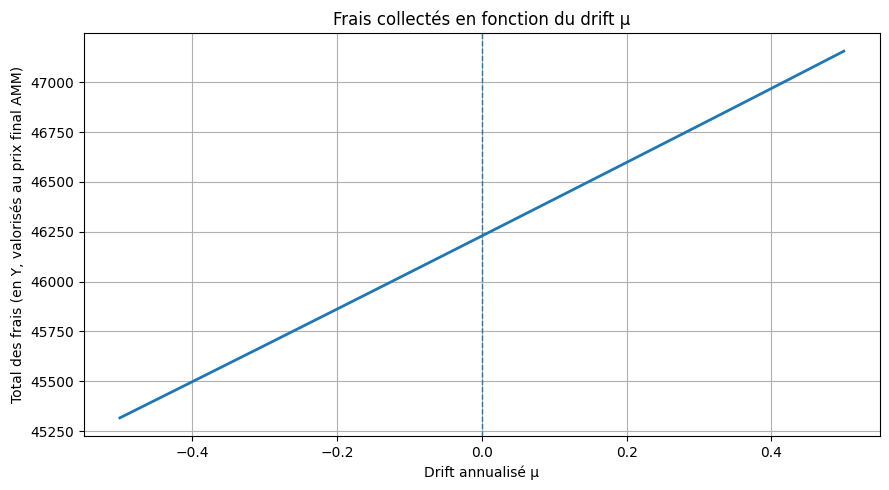

In [9]:
mus = np.linspace(-0.50, 0.50, 41)
fees_vs_mu = []

for m in mus:
    out_m = run_with_mu(m)
    fees_vs_mu.append(total_fees_final_Y(out_m, price_for_valuation="amm"))

plt.figure(figsize=(9, 5))
plt.plot(mus, fees_vs_mu, linewidth=2)
plt.axvline(0.0, linestyle="--", linewidth=1)
plt.title("Frais collectés en fonction du drift μ")
plt.xlabel("Drift annualisé μ")
plt.ylabel("Total des frais (en Y, valorisés au prix final AMM)")
plt.grid(True)
plt.tight_layout()
plt.show()

### 4.5) Fees en fonction de **Φ** (taux de frais) et de l’**échantillonnage** (dt)

Objectif (même protocole que partout) :
- on génère **UNE** trajectoire CEX haute fréquence (1 minute) avec un seed fixe ;
- on **réutilise** ce même chemin pour :
  1) balayer Φ (tout le reste constant),
  2) sous-échantillonner le prix CEX (dt plus gros).

On valorise tous les frais en **Token Y**, en convertissant le stock de frais en X au **prix final AMM** (comme dans ton snippet).

<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\P'
<>:60: SyntaxWarning: invalid escape sequence '\P'
<>:69: SyntaxWarning: invalid escape sequence '\P'
<>:58: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\P'
<>:60: SyntaxWarning: invalid escape sequence '\P'
<>:69: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_23146/3612929876.py:58: SyntaxWarning: invalid escape sequence '\s'
  label='Limite continue approx. $(\sigma^2/8)\,V_0\,T$')
/tmp/ipykernel_23146/3612929876.py:59: SyntaxWarning: invalid escape sequence '\P'
  ax1.set_title("Frais collectés en fonction de $\Phi$")
/tmp/ipykernel_23146/3612929876.py:60: SyntaxWarning: invalid escape sequence '\P'
  ax1.set_xlabel("Taux de frais $\Phi$ (%)")
/tmp/ipykernel_23146/3612929876.py:69: SyntaxWarning: invalid escape sequence '\P'
  ax2.set_ylabel("Total des frais (en valeur Y) pour $\Phi = 0.3\%$")


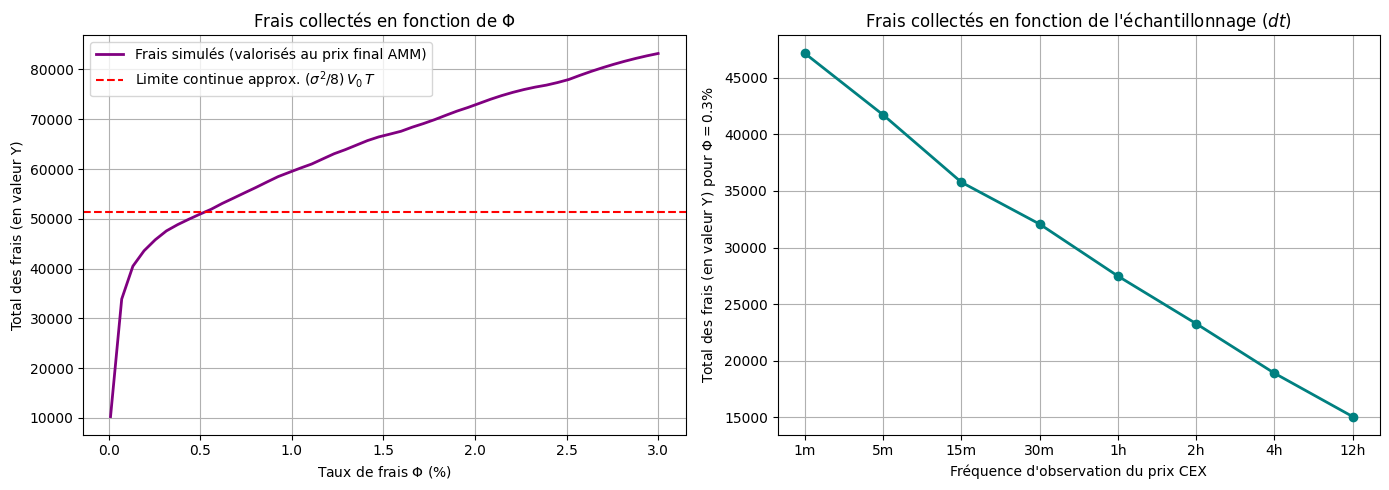

Repères :
  V0 (valeur initiale pool, Y) = 20,000,000
  Limite continue approx       = 51,369.86 Y


In [10]:

# Génération de la trajectoire de base (seed fixe)

T = years_from_days(30)                 # 30 jours (en années)
dt_base = years_from_minutes(1)         # 1 minute (en années)

t_base = make_time_grid(T, dt_base)
W_base = brownian_path(len(t_base), dt_base, seed=42)

mu, sigma, S0 = 0.0, 0.5, 1000.0
S_cex_base = gbm_from_brownian(t_base, W_base, mu=mu, sigma=sigma, S0=S0)

initial_liquidity_x = 10_000.0

# Fees en fonction de Phi

phis = np.linspace(0.0001, 0.03, 50)  # 0.01% à 3%
fees_vs_phi = []

for phi in phis:
    out_phi = simulate_on_price_path(
        S_cex_base, dt_base,
        phi=float(phi),
        initial_liquidity_x=initial_liquidity_x,
        alpha=1.0, latency_minutes=0.0, retarget=True
    )
    fees_vs_phi.append(total_fees_final_Y(out_phi, price_for_valuation="amm"))

# Limite "continue" souvent citée (ordre de grandeur) :

V0 = 2.0 * initial_liquidity_x * S0
theoretical_limit = (sigma**2 / 8.0) * V0 * T

# Fees en fonction de l'échantillonnage (dt)
#
step_multipliers = [1, 5, 15, 30, 60, 120, 240, 720]  # en minutes
dt_labels = ['1m', '5m', '15m', '30m', '1h', '2h', '4h', '12h']
fixed_phi = 0.003  # 0.3%

fees_vs_dt = []
for step in step_multipliers:
    S_sub = S_cex_base[::step]
    dt_sub = dt_base * step
    out_dt = simulate_on_price_path(
        S_sub, dt_sub,
        phi=fixed_phi,
        initial_liquidity_x=initial_liquidity_x,
        alpha=1.0, latency_minutes=0.0, retarget=True
    )
    fees_vs_dt.append(total_fees_final_Y(out_dt, price_for_valuation="amm"))

# Affichage des résultats

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Fees vs Phi
ax1.plot(phis * 100, fees_vs_phi, color='purple', linewidth=2, label='Frais simulés (valorisés au prix final AMM)')
ax1.axhline(theoretical_limit, color='red', linestyle='--',
            label='Limite continue approx. $(\sigma^2/8)\,V_0\,T$')
ax1.set_title("Frais collectés en fonction de $\Phi$")
ax1.set_xlabel("Taux de frais $\Phi$ (%)")
ax1.set_ylabel("Total des frais (en valeur Y)")
ax1.grid(True)
ax1.legend()

# PFees vs Échantillonnage
ax2.plot(dt_labels, fees_vs_dt, marker='o', color='teal', linewidth=2)
ax2.set_title("Frais collectés en fonction de l'échantillonnage ($dt$)")
ax2.set_xlabel("Fréquence d'observation du prix CEX")
ax2.set_ylabel("Total des frais (en valeur Y) pour $\Phi = 0.3\%$")
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Repères :")
print(f"  V0 (valeur initiale pool, Y) = {V0:,.0f}")
print(f"  Limite continue approx       = {theoretical_limit:,.2f} Y")

## 5) LP vs HODL (même run, métriques cohérentes)

- **HODL** : tu gardes (x0, y0) constants  
- **LP** : tu détiens une part *lp_share* de la pool (x(t), y(t))

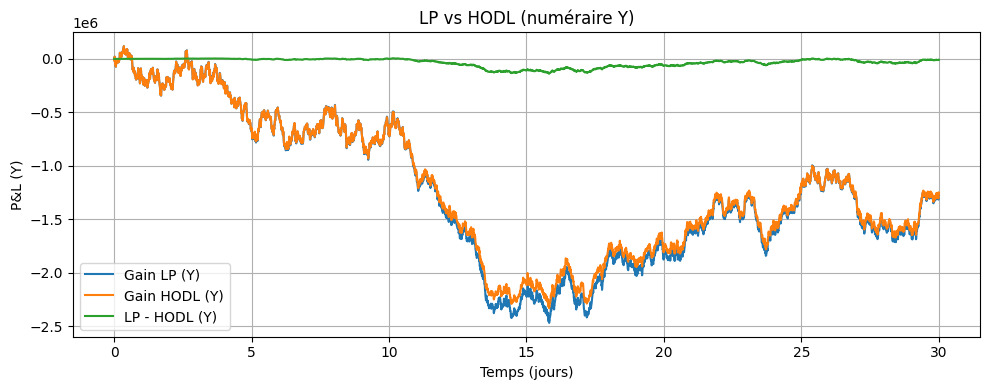

{'V0_Y': 20000000.0,
 'V_lp_end_Y': 18730478.850147195,
 'V_hodl_end_Y': 18738371.39411673,
 'LP_minus_HODL_end_Y': -7892.5439695343375,
 'fees_end_Y': 34604.73209253412,
 'price_tracking_rmse': 1.995628191329525}

In [11]:
lp_share = 1.0  # 1.0 = 100% de la pool

S = out["S_cex"]
x, y = out["x"], out["y"]

x0 = x[0] * lp_share
y0 = y[0] * lp_share
V0 = x0 * S[0] + y0

V_hodl = hodl_value_Y(x0, y0, S)
V_lp = lp_value_Y(x, y, S, lp_share=lp_share)

plt.figure(figsize=(10, 4))
plt.plot(out["t"] * DAYS_PER_YEAR, V_lp - V0, label="Gain LP (Y)")
plt.plot(out["t"] * DAYS_PER_YEAR, V_hodl - V0, label="Gain HODL (Y)")
plt.plot(out["t"] * DAYS_PER_YEAR, V_lp - V_hodl, label="LP - HODL (Y)")
plt.xlabel("Temps (jours)")
plt.ylabel("P&L (Y)")
plt.title("LP vs HODL (numéraire Y)")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

summarize_run(out, lp_share=lp_share)

## 6) Interactivité (pool + swaps)

Deux widgets :
1. **Explorateur de paramètres** (T, dt, σ, μ, φ, liquidité, alpha, latence) → plots automatiques  
2. **Pool interactive** à un instant *t* : visualisation de la courbe *x·y=k* et effet d’un swap (X→Y ou Y→X)

> Vaut mieux exécuter dans colab pour voir les widgets

In [12]:

# Explorateur de paramètres (réserves X/Y + fees cumulés

w_days  = widgets.IntSlider(value=30, min=1, max=180, step=1, description="T (jours)")
w_dt    = widgets.IntSlider(value=10, min=1, max=60, step=1, description="dt (min)")
w_phi   = widgets.FloatSlider(value=0.003, min=0.0, max=0.05, step=0.001, description="phi")
w_Lx    = widgets.FloatSlider(value=10_000, min=1_000, max=100_000, step=1_000, description="Lx")
w_alpha = widgets.FloatSlider(value=1.0, min=0.05, max=1.0, step=0.05, description="alpha")
w_lat   = widgets.FloatSlider(value=0.0, min=0.0, max=30.0, step=1.0, description="lat (min)")
w_seed  = widgets.IntText(value=42, description="seed")

out_box = widgets.Output()

def _run_and_plot(change=None):
    with out_box:
        clear_output(wait=True)

        p = SimParams(
            T=years_from_days(w_days.value),
            dt=years_from_minutes(w_dt.value),

            # Valeurs fixes
            mu=0.0,
            sigma=0.5,
            S0=1000.0,
            seed=int(w_seed.value),

            phi=float(w_phi.value),
            initial_liquidity_x=float(w_Lx.value),

            alpha=float(w_alpha.value),
            latency_minutes=float(w_lat.value),
            retarget=True,
        )

        out_loc = simulate_uniswap_v2(p)

        t_days = out_loc["t"] * DAYS_PER_YEAR
        S = out_loc["S_cex"]
        P = out_loc["P_amm"]
        x = out_loc["x"]
        y = out_loc["y"]


        # Prix : S_CEX & P_AMM

        plt.figure(figsize=(10, 4.5))
        plt.plot(t_days, S, linewidth=2, label="S_CEX (prix externe)")
        plt.plot(t_days, P, linewidth=2, label="P_AMM (y/x)")
        plt.title("Explorateur : Prix CEX vs Prix AMM")
        plt.xlabel("Temps (jours)")
        plt.ylabel("Prix (en Y par X)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


        # 2) Réserves X & Y (mêmes axes, couleurs différentes)

        plt.figure(figsize=(10, 4.2))
        l1, = plt.plot(t_days, x, linewidth=2, label="Réserve X")
        l2, = plt.plot(t_days, y, linewidth=2, label="Réserve Y")
        plt.title("Évolution des réserves de la pool (X et Y)")
        plt.xlabel("Temps (jours)")
        plt.ylabel("Réserves (unités)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Fees cumulés (en Y)

        fee_x_cum = None
        fee_y_cum = None

        if "fee_x_cum" in out_loc and "fee_y_cum" in out_loc:
            fee_x_cum = np.asarray(out_loc["fee_x_cum"], dtype=float)
            fee_y_cum = np.asarray(out_loc["fee_y_cum"], dtype=float)
        elif "fee_x" in out_loc and "fee_y" in out_loc:
            fee_x_cum = np.cumsum(np.asarray(out_loc["fee_x"], dtype=float))
            fee_y_cum = np.cumsum(np.asarray(out_loc["fee_y"], dtype=float))
        else:
            print("Note: out_loc ne contient pas fee_x_cum/fee_y_cum ni fee_x/fee_y -> fees cumulés non traçables.")

        if fee_x_cum is not None and fee_y_cum is not None:
            fees_cum_Y = fee_y_cum + fee_x_cum * np.asarray(P, dtype=float)

            plt.figure(figsize=(10, 4.0))
            plt.plot(t_days, fees_cum_Y, linewidth=2)
            plt.title("Fees cumulés (valorisés en Y au prix AMM courant)")
            plt.xlabel("Temps (jours)")
            plt.ylabel("Fees cumulés (Y)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        print(summarize_run(out_loc))

for w in [w_days, w_dt, w_phi, w_Lx, w_alpha, w_lat, w_seed]:
    w.observe(_run_and_plot, names="value")

controls = widgets.VBox([
    widgets.HBox([w_days, w_dt, w_seed]),
    widgets.HBox([w_phi, w_Lx, w_alpha]),
    widgets.HBox([w_lat]),
])

display(widgets.HTML("<b>Explorateur de paramètres</b>"))
display(controls, out_box)
_run_and_plot()

HTML(value='<b>Explorateur de paramètres</b>')

Output()

In [13]:

# Sandbox Pool (x,y) : liquidité, prix, slippage & impact

display(widgets.HTML("<hr><b>Sandbox Pool (x,y) : liquidité, prix, slippage & impact</b>"))

w2_lock_price = widgets.Checkbox(value=True, description="Verrouiller le prix (y = x·P)")

w2_x = widgets.FloatLogSlider(value=10_000.0, base=10, min=2, max=7, step=0.05,
                              description="x", readout_format=".2f")
w2_P = widgets.FloatLogSlider(value=1000.0, base=10, min=0, max=6, step=0.05,
                              description="P (y/x)", readout_format=".2f")
w2_y = widgets.FloatLogSlider(value=10_000_000.0, base=10, min=2, max=10, step=0.05,
                              description="y", readout_format=".2f")


w2_phi = widgets.FloatSlider(value=0.003, min=0.0, max=0.05, step=0.001, description="phi")

w2_dir = widgets.Dropdown(
    options=[("Y → X (buy X)", "y_for_x"), ("X → Y (sell X)", "x_for_y")],
    value="y_for_x",
    description="Swap"
)
w2_amt = widgets.FloatLogSlider(value=1_000.0, base=10, min=0, max=7, step=0.05,
                                description="amount_in", readout_format=".2f")
w2_sweep = widgets.FloatLogSlider(value=100_000.0, base=10, min=0, max=8, step=0.05,
                                  description="sweep max", readout_format=".2f")

sandbox_box = widgets.Output()

def _plot_sandbox(change=None):
    with sandbox_box:
        clear_output(wait=True)

        phi = float(w2_phi.value)

        x = float(w2_x.value)
        if w2_lock_price.value:
            P = float(w2_P.value)
            y = x * P
        else:
            y = float(w2_y.value)
            P = y / max(1e-18, x)

        k = x * y
        V_Y = x * P + y  # valeur approx en Y au prix spot

        # Swap preview
        amount_in = float(w2_amt.value)
        if w2_dir.value == "y_for_x":
            x2, y2, dx_out, fee_y = swap_y_for_x(x, y, amount_in, phi)
            P2 = y2 / x2
            eff_price = amount_in / max(1e-18, dx_out)  # Y par X
            slip_pct = (eff_price / P - 1.0) * 100.0
            desc = f"Tu envoies {amount_in:,.2f} Y → tu reçois {dx_out:,.6f} X (fee {fee_y:,.2f} Y)"
        else:
            x2, y2, dy_out, fee_x = swap_x_for_y(x, y, amount_in, phi)
            P2 = y2 / x2
            eff_price = dy_out / max(1e-18, amount_in)  # Y par X
            slip_pct = (eff_price / P - 1.0) * 100.0
            desc = f"Tu envoies {amount_in:,.6f} X → tu reçois {dy_out:,.2f} Y (fee {fee_x:,.6f} X)"

        impact_pct = (P2 / P - 1.0) * 100.0

        print(f"Réserves : x={x:,.2f}   y={y:,.2f}   k=x·y={k:,.2e}")
        print(f"Prix spot : P=y/x={P:,.6f}   Valeur pool ~ {V_Y:,.2f} Y")
        print(f"Frais φ : {phi*100:.3f}%")
        print(desc)
        print(f"Après swap : x'={x2:,.2f}   y'={y2:,.2f}   P'={P2:,.6f}")
        print(f"  • Price impact (P' vs P) : {impact_pct:+.3f}%")
        print(f"  • Prix effectif          : {eff_price:,.6f} Y/X   (slippage {slip_pct:+.3f}%)")

        # Courbe x·y=k
        xs = np.linspace(max(1e-12, 0.3*x), 1.7*x, 250)
        ys = k / xs

        plt.figure(figsize=(7, 5))
        plt.plot(xs, ys, linewidth=2, label="Courbe x·y=k")
        plt.scatter([x], [y], s=60, label="Avant")
        plt.scatter([x2], [y2], s=60, label="Après swap")
        plt.xlabel("Réserve X")
        plt.ylabel("Réserve Y")
        plt.title("Constante x·y=k (impact du swap)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Impact vs taille de trade
        sweep_max = float(w2_sweep.value)
        amts = np.linspace(0.0, sweep_max, 80)

        impacts = []
        for a in amts:
            if w2_dir.value == "y_for_x":
                xa, ya, _, _ = swap_y_for_x(x, y, float(a), phi)
            else:
                xa, ya, _, _ = swap_x_for_y(x, y, float(a), phi)
            Pa = ya / xa
            impacts.append((Pa / P - 1.0) * 100.0)

        plt.figure(figsize=(8, 4))
        plt.plot(amts, impacts, linewidth=2)
        plt.xlabel("Taille du swap (token d'entrée)")
        plt.ylabel("Impact prix (%)")
        plt.title("Impact prix vs taille de trade (plus de liquidité ⇒ courbe plus plate)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

for w in [w2_lock_price, w2_x, w2_P, w2_y, w2_phi, w2_dir, w2_amt, w2_sweep]:
    w.observe(_plot_sandbox, names="value")

sandbox_controls = widgets.VBox([
    widgets.HBox([w2_lock_price, w2_phi]),
    widgets.HBox([w2_x, w2_P, w2_y]),
    widgets.HBox([w2_dir, w2_amt, w2_sweep]),
])

display(sandbox_controls, sandbox_box)
_plot_sandbox()

HTML(value='<hr><b>Sandbox Pool (x,y) : liquidité, prix, slippage & impact</b>')

Output()